In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns

In [10]:
x, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

In [11]:
df = pd.DataFrame(x, columns=['x1', 'x2'])
df['y'] = y 

df.head(5)

,x1,x2,y
0,-0.111667,0.520224,1
1,1.142650,-0.342577,1
2,0.795558,-0.011442,1
3,0.111827,-0.551932,1
4,-0.816466,0.543996,0


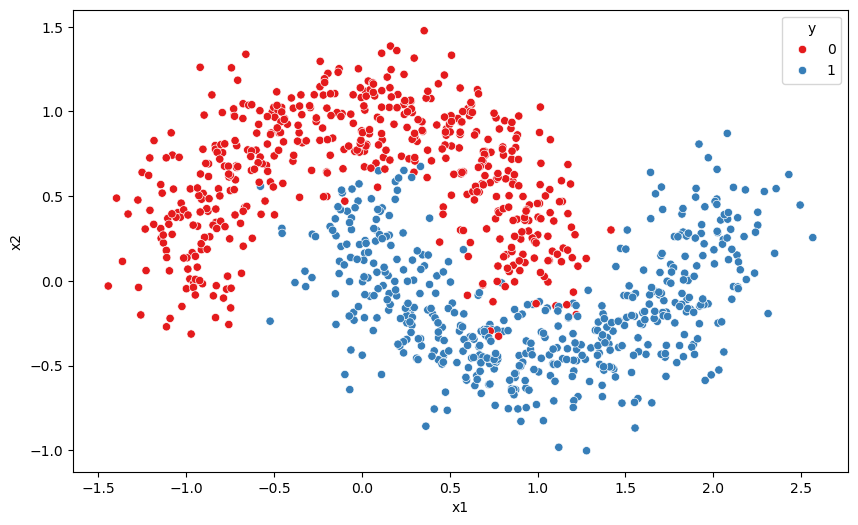

In [12]:
# plot scatter plot 
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='x1', y='x2', hue='y', palette='Set1')
plt.show()

In [16]:
# prepate the dependent and independent variables

x_a = df.iloc[:, :-1]
y_a = df["y"]


In [17]:
# train test split the data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_a, y_a, test_size=0.2, random_state=42)

In [19]:
# now prepare the model

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

## Train the Models

In [23]:
# train the Desicion Tree Models

dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
dt.score(x_test, y_test), dt.score(x_train, y_train)

(0.96, 1.0)

In [24]:
# train the SVC model

svc = SVC()
svc.fit(x_train, y_train)
svc.score(x_test, y_test), svc.score(x_train, y_train)

(0.98, 0.96875)

In [25]:
# train the gaussian naive bayes model
gnb = GaussianNB()
gnb.fit(x_train, y_train)
gnb.score(x_test, y_test), gnb.score(x_train, y_train)

(0.855, 0.8675)

## Now we will use Ensemble Learning Voting Classifier to combine the predictions of the three models we trained above.

In [26]:
from sklearn.ensemble import VotingClassifier

In [27]:
# prepare the list of models that we want to use
models = [
    ('dt', DecisionTreeClassifier()),
    ('svc', SVC()),
    ('gnb', GaussianNB())
]

In [28]:
# prepare the voting classifier
voting = VotingClassifier(estimators=models)
voting.fit(x_train, y_train)

VotingClassifier(estimators=[('dt', DecisionTreeClassifier()), ('svc', SVC()),
                             ('gnb', GaussianNB())])

In [29]:
# now check the accuracy of the voting classifier
voting.score(x_test, y_test), voting.score(x_train, y_train)

(0.965, 0.975)

In [30]:
# You could train the model with hyperparameter tuning

In [32]:
# now verify the avarage accuracy of the models

prd = {"dt": dt.predict(x_test),
       "svc": svc.predict(x_test),
       "gnb": gnb.predict(x_test),
       "voting": voting.predict(x_test)
       }


pd.DataFrame(prd)

,dt,svc,gnb,voting
0,1,1,1,1
1,0,0,0,0
2,1,1,1,1
3,0,0,0,0
4,1,1,1,1
...,...,...,...,...
195,0,0,1,0
196,1,1,1,1
197,0,0,0,0
198,0,1,1,1


In [33]:
# here you could see that the voting classifier is better than the other models and using the Mod of the models